In [1]:
import pandas as pd

df = pd.read_csv('../data/cars.csv')
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [3]:
from sklearn.preprocessing import OrdinalEncoder

oe_seller = OrdinalEncoder(categories=[['Individual','Dealer','Trustmark Dealer']])
df['seller_type'] = oe_seller.fit_transform(df[['seller_type']])

oe_owner = OrdinalEncoder(categories=[['Test Drive Car','First Owner','Second Owner','Third Owner','Fourth & Above Owner']])
df['owner'] = oe_owner.fit_transform(df[['owner']])

oe_trans = OrdinalEncoder(categories=[['Manual','Automatic']])
df['transmission'] = oe_trans.fit_transform(df[['transmission']])

In [4]:
oe_fuel = OrdinalEncoder(categories=[['LPG','CNG','Electric','Petrol','Diesel']])
df['fuel'] = oe_fuel.fit_transform(df[['fuel']])

In [5]:
from datetime import date
df['age'] = date.today().year - df['year']

In [6]:
df['brand'] = df['name'].apply(lambda x: x.split(' ')[0])

In [7]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
encoded_data = ohe.fit_transform(df[['brand']])
encoded_df = pd.DataFrame(encoded_data,
                         columns=ohe.get_feature_names_out(['brand']))
encoded_df


,brand_Ambassador,brand_Audi,brand_BMW,brand_Chevrolet,brand_Daewoo,brand_Datsun,brand_Fiat,brand_Force,brand_Ford,brand_Honda,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_OpelCorsa,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4335,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4336,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4337,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4338,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df = pd.concat([df.drop(columns=['brand']),encoded_df],axis=1)

In [9]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,age,brand_Ambassador,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_OpelCorsa,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,Maruti 800 AC,2007,60000,70000,3.0,0.0,0.0,1.0,19,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Maruti Wagon R LXI Minor,2007,135000,50000,3.0,0.0,0.0,1.0,19,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Hyundai Verna 1.6 SX,2012,600000,100000,4.0,0.0,0.0,1.0,14,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Datsun RediGO T Option,2017,250000,46000,3.0,0.0,0.0,1.0,9,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Honda Amaze VX i-DTEC,2014,450000,141000,4.0,0.0,0.0,2.0,12,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
X,y=df.drop(columns=['name','year','selling_price']),df['selling_price']

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
import mlflow
mlflow.sklearn.autolog()

mlflow.set_experiment('Cars_learn')

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
with mlflow.start_run(run_name='baseline_random_forest'):
    rf = RandomForestRegressor()
    rf.fit(X_train,y_train)
    rf.score(X_test,y_test)

2026/06/15 20:15:34 INFO mlflow.tracking.fluent: Experiment with name 'Cars_learn' does not exist. Creating a new experiment.
2026/06/15 20:15:34 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\ml\mlops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/15 20:15:35 WARNING mlflow.util

In [13]:
import mlflow
from sklearn.ensemble import RandomForestRegressor
with mlflow.start_run(run_name='start_tuning_rf'):
    rf = RandomForestRegressor(random_state=42,
                               max_depth=10,
                               n_estimators=200,
                               min_samples_leaf=2,)
    rf.fit(X_train,y_train)
    rf.score(X_test,y_test)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34],
 [Text(0, 0, 'km_driven'),
  Text(1, 0, 'fuel'),
  Text(2, 0, 'seller_type'),
  Text(3, 0, 'transmission'),
  Text(4, 0, 'owner'),
  Text(5, 0, 'age'),
  Text(6, 0, 'brand_Ambassador'),
  Text(7, 0, 'brand_Audi'),
  Text(8, 0, 'brand_BMW'),
  Text(9, 0, 'brand_Chevrolet'),
  Text(10, 0, 'brand_Daewoo'),
  Text(11, 0, 'brand_Datsun'),
  Text(12, 0, 'brand_Fiat'),
  Text(13, 0, 'brand_Force'),
  Text(14, 0, 'brand_Ford'),
  Text(15, 0, 'brand_Honda'),
  Text(16, 0, 'brand_Hyundai'),
  Text(17, 0, 'brand_Isuzu'),
  Text(18, 0, 'brand_Jaguar'),
  Text(19, 0, 'brand_Jeep'),
  Text(20, 0, 'brand_Kia'),
  Text(21, 0, 'brand_Land'),
  Text(22, 0, 'brand_MG'),
  Text(23, 0, 'brand_Mahindra'),
  Text(24, 0, 'brand_Maruti'),
  Text(25, 0, 'brand_Mercedes-Benz'),
  Text(26, 0, 'brand_Mitsubishi'),
  

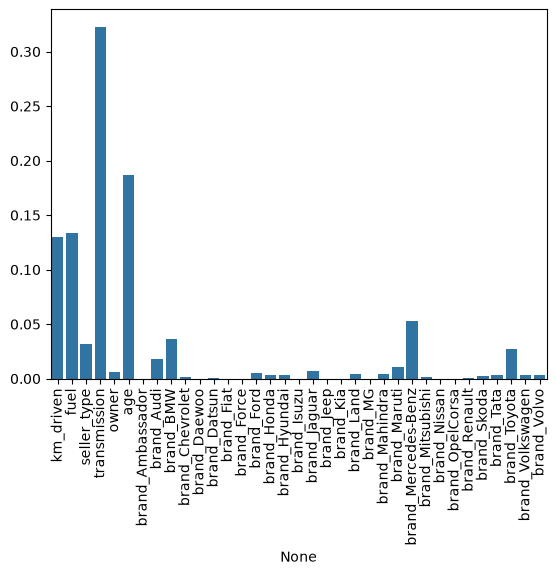

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
x = X.columns
y = rf.feature_importances_
sns.barplot(x=x,y=y)
plt.xticks(rotation=90)

In [28]:
from sklearn.model_selection import RandomizedSearchCV
rf = RandomForestRegressor(random_state=42)
parameters = {'max_depth':[7,10,15],
              'n_estimators':[100,200],
              'min_samples_leaf':[1,2,3],
              'max_features':[1,2]}
with mlflow.start_run(run_name='crossvalidation'):
    rcv = RandomizedSearchCV(rf,parameters,random_state=42)
    search = rcv.fit(X_train,y_train)
    print(search.best_params_)

2026/06/15 20:21:24 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\ml\mlops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/15 20:21:40 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\ml\mlops\.venv\Lib\site-packages\mlflow\types\utils.py:440:

{'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 2, 'max_depth': 15}
